## 2.6 양자 워크 — 양자 컴퓨팅으로 그래프 탐색 (Quantum Walks)

In [1]:
# 필요한 라이브러리 불러오기
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# 순환 그래프 위의 양자 워크 회로를 만드는 함수
def create_quantum_walk_circuit(num_qubits, num_steps):
    qc = QuantumCircuit(num_qubits)
       # 보행자를 모든 노드의 중첩 상태로 초기화
    for qubit in range(num_qubits):
        qc.h(qubit)

    # 동전·이동 연산자 정의
    coin = QuantumCircuit(1)
    coin.h(0)

    shift = QuantumCircuit(num_qubits)
    for i in range(num_qubits):
        shift.cx(i, (i + 1) % num_qubits)

    # 지정된 스텝 수만큼 동전·이동 연산자 적용
    for _ in range(num_steps):
        for qubit in range(num_qubits):
            qc.append(coin, [qubit])
        qc.append(shift, range(num_qubits))

    # 모든 큐비트 측정
    qc.measure_all()

    return qc

In [3]:
# 파라미터
num_qubits = 3  # 큐비트 수(순환 그래프의 노드)
num_steps = 2  # 양자 워크 스텝 수

In [4]:
# 양자 워크 회로 생성
qc = create_quantum_walk_circuit(num_qubits, num_steps)

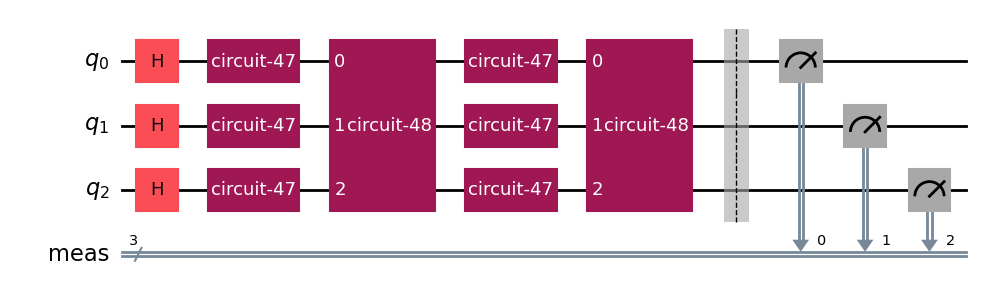

In [5]:
# 회로 시각화
qc.draw('mpl')
plt.show()

In [6]:
# Qiskit Aer 시뮬레이터 초기화
simulator = AerSimulator()

In [7]:
# 시뮬레이터용으로 회로 트랜스파일
compiled_circuit = transpile(qc, simulator)

In [8]:
# Qiskit Aer 시뮬레이터에서 회로 실행
result = simulator.run(compiled_circuit, shots=1000).result()

In [9]:
# 측정 결과 얻기
counts = result.get_counts(compiled_circuit)

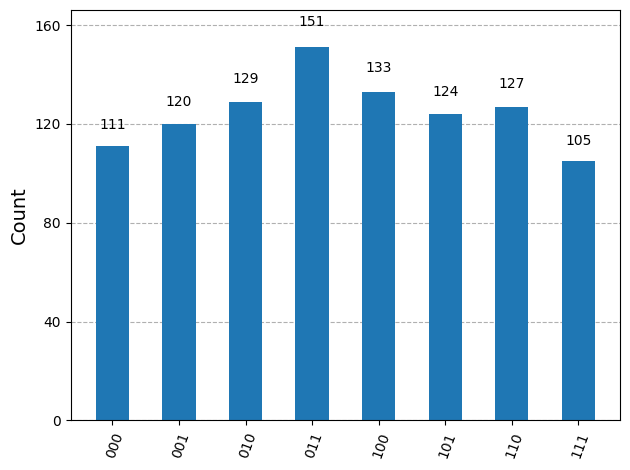

In [10]:
# 결과 그리기
plot_histogram(counts)
plt.show()